In [ ]:
!pip install seaborn -q

In [ ]:
# Pandas is used for loading and processing datasets.
import pandas as pd
# NumPy is used for numerical operations.
import numpy as np
# Matplotlib and Seaborn are used for plotting graphs.
import matplotlib.pyplot as plt
import seaborn as sns
# Train-test split is used to divide the dataset into training and testing sets.
from sklearn.model_selection import train_test_split
# LabelEncoder converts text values into numeric values.
# StandardScaler scales numerical features for better model performance.
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/project1/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("Shape :", df.shape)

df.head()

Dataset Loaded Successfully
Shape : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Display the number of rows and columns.
print("Dataset Shape:", df.shape)
# Show information about data types and missing values.
df.info()
# Display statistical summary of numerical columns.
df.describe()
# Count missing values in each column.
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [ ]:
# customerID is only an identifier and does not help in prediction.
df.drop("customerID", axis=1, inplace=True)
# Convert TotalCharges from text to numeric values.
# Invalid values are replaced with NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# Replace missing values with the median value.
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median())
# Display cleaned data.
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Duplicate records can affect model performance.
# This cell checks whether duplicate rows exist in the dataset.
print("Duplicate Rows:", df.duplicated().sum())
# Remove duplicate rows if any exist.
df = df.drop_duplicates()
# Display updated dataset size.
print("Dataset Shape After Removing Duplicates:", df.shape)

Duplicate Rows: 22
Dataset Shape After Removing Duplicates: (7021, 20)


In [ ]:
# Machine Learning algorithms cannot work directly with text values.
# Therefore, all categorical columns are converted into numeric values.
encoder = LabelEncoder()
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])
# Display first five rows after encoding.
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


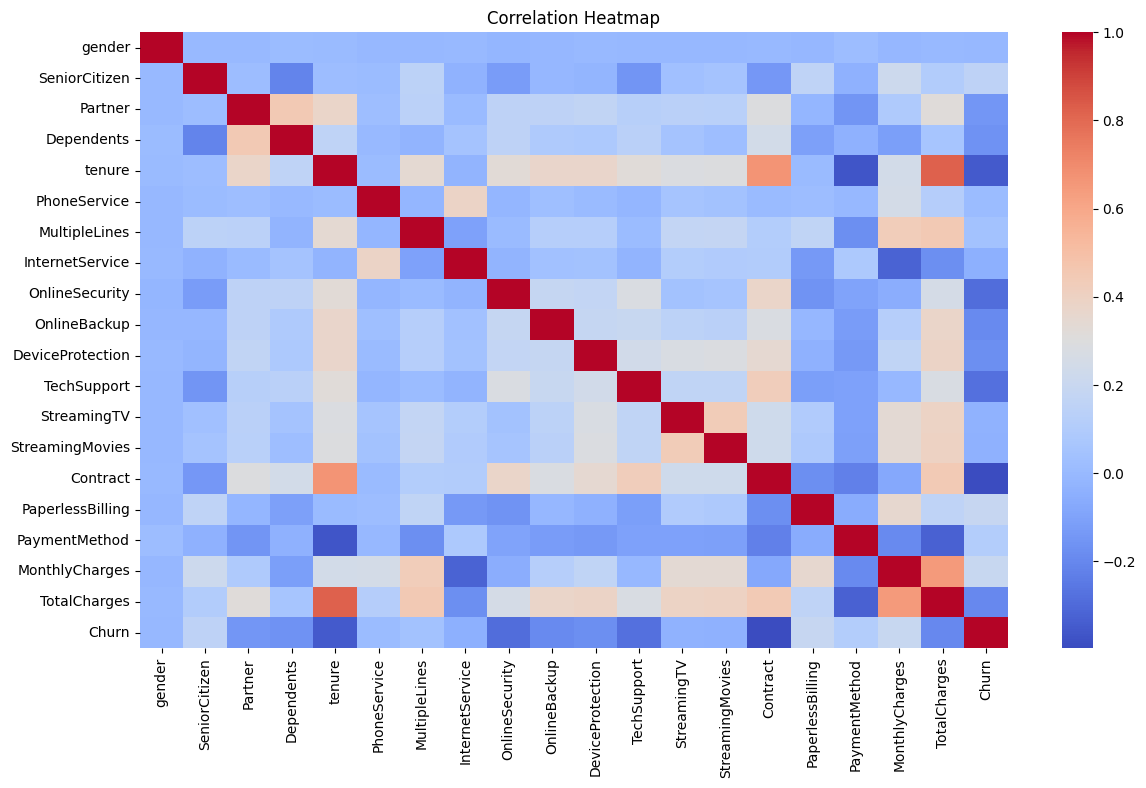

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation helps understand relationships
# between numerical features.

plt.figure(figsize=(14,8))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Features (X) are input variables used for prediction.
X = df.drop("Churn", axis=1)
# Target (y) is the output variable that the model will predict.
y = df["Churn"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7021, 19)
Target Shape: (7021,)


In [ ]:
# Scaling makes numerical features
# have similar ranges.

# This improves the performance of
# algorithms such as KNN and Logistic Regression.

# Ensure X is fully numeric by encoding any remaining object columns
# This step is necessary if X was created before df was fully encoded.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Create a copy to avoid SettingWithCopyWarning
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = le.fit_transform(X_encoded[col])

scaler = StandardScaler()
X = scaler.fit_transform(X_encoded)

In [ ]:
# Split the dataset into training and testing data.
# 80% of the data is used for training.
# 20% is used to evaluate model performance.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 5616
Testing Samples: 1405


In [ ]:
# Purpose:
# Train a Logistic Regression model to predict
# whether a customer will churn or not.
# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

# Make predictions
log_pred = log_model.predict(X_test)

# Calculate model accuracy
log_acc = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy:", round(log_acc*100,2),"%")

Logistic Regression Accuracy: 79.57 %


In [ ]:
# Purpose:
# Train a Decision Tree model for customer churn prediction.
tree_model = DecisionTreeClassifier(
    random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)
print("Decision Tree Accuracy:", round(tree_acc*100,2),"%")

Decision Tree Accuracy: 73.67 %


In [ ]:
# Purpose:
# Random Forest combines multiple Decision Trees
# to improve prediction accuracy.

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_acc*100,2),"%")

Random Forest Accuracy: 78.43 %


In [ ]:
# Purpose:
# KNN predicts the class based on the
# nearest neighboring data points.

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", round(knn_acc*100,2),"%")

KNN Accuracy: 76.16 %


In [ ]:
# Compare the performance of all trained models.

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"],
    "Accuracy":[
        log_acc,
        tree_acc,
        rf_acc,
        knn_acc]})

results["Accuracy"] = results["Accuracy"]*100
results = results.sort_values( by="Accuracy", ascending=False)
results

,Model,Accuracy
0,Logistic Regression,79.572954
2,Random Forest,78.434164
3,KNN,76.156584
1,Decision Tree,73.665480


/tmp/ipykernel_745/2801048637.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="Accuracy", palette="viridis")


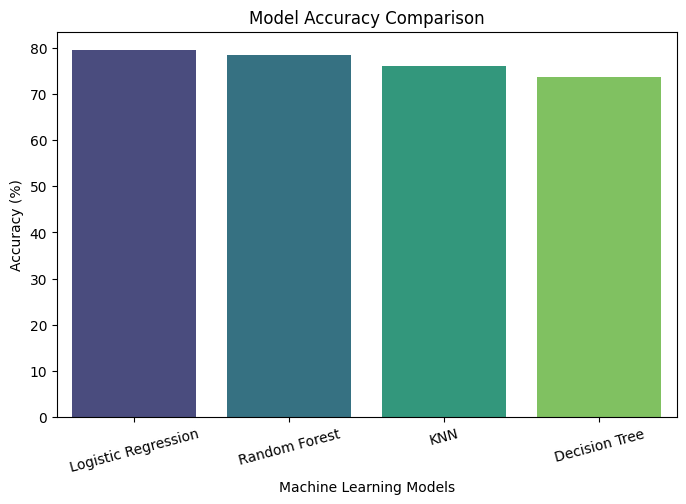

In [ ]:
# Purpose:
# Visualize model accuracy using a bar chart.
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="Accuracy", palette="viridis")
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)
plt.show()

In [ ]:
# ==========================================
# Cell 19: Classification Report
# ==========================================

# Purpose:
# Evaluate the Random Forest model using
# Precision, Recall and F1-Score.

print(classification_report(

    y_test,

    rf_pred

))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1053
           1       0.59      0.46      0.52       352

    accuracy                           0.78      1405
   macro avg       0.71      0.68      0.69      1405
weighted avg       0.77      0.78      0.77      1405



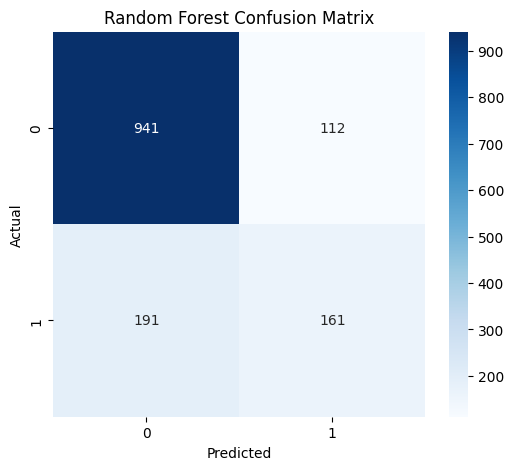

In [ ]:
# Purpose:
# Display correct and incorrect predictions
# made by the Random Forest model.

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
# Purpose:
# Compare all trained models and identify
# which model achieved the highest accuracy.
best_model = results.loc[results["Accuracy"].idxmax()]

print("Best Model")
print("----------------------")
print("Model Name :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"],2),"%")

Best Model
----------------------
Model Name : Logistic Regression
Accuracy   : 79.57 %


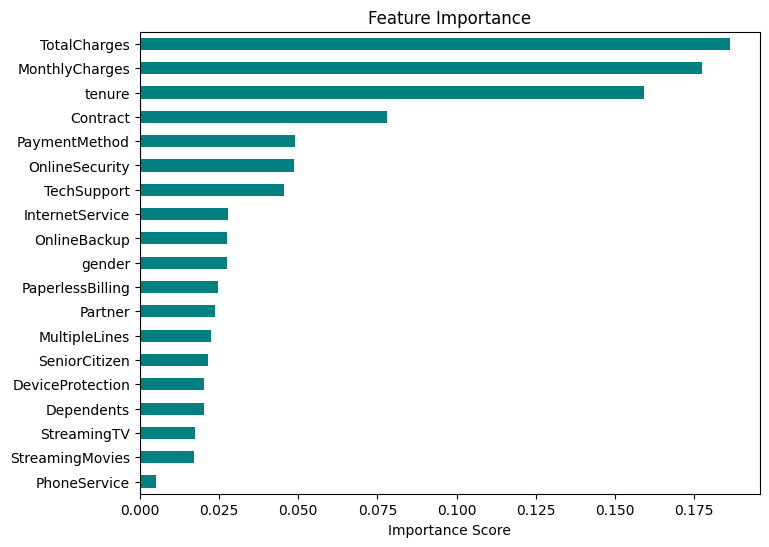

In [ ]:
# Purpose:
# Display which features contribute the most
# to customer churn prediction.

importance = pd.Series(rf_model.feature_importances_, index=df.drop("Churn",axis=1).columns)
importance = importance.sort_values()
plt.figure(figsize=(8,6))
importance.plot(kind="barh", color="teal")

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
# Purpose:
# Predict whether a new customer will churn.

sample_customer = X_test[0].reshape(1,-1)
prediction = rf_model.predict(sample_customer)
if prediction[0] == 1:
    print("Prediction : Customer Will Churn")
else:
    print("Prediction : Customer Will Stay")

Prediction : Customer Will Churn


In [ ]:
# Purpose:
# Save the trained Random Forest model
# so it can be reused later.

import joblib
joblib.dump(rf_model, "customer_churn_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
# Purpose:
# Load the previously saved model
# without retraining.

loaded_model = joblib.load("customer_churn_model.pkl")
print("Saved Model Loaded Successfully")

Saved Model Loaded Successfully


In [ ]:
# Purpose:
# Verify that the loaded model
# predicts correctly.
prediction = loaded_model.predict(X_test[:5])
print(prediction)

[1 0 0 0 0]


/tmp/ipykernel_745/1505740587.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


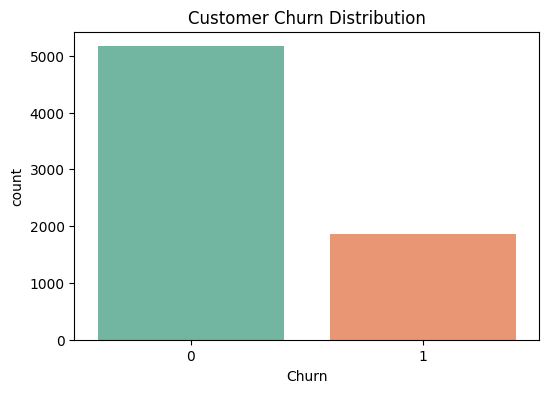

In [ ]:
# Purpose:
# Visualize the number of customers
# who stayed and who churned.

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn", palette="Set2")

plt.title("Customer Churn Distribution")
plt.show()

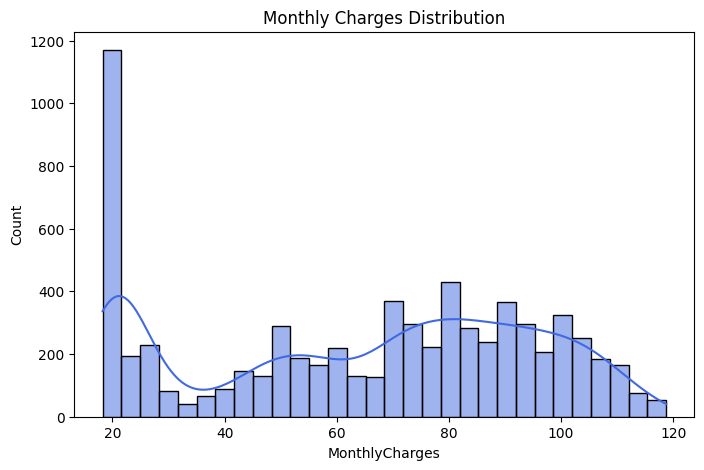

In [ ]:
# Purpose:
# Observe how Monthly Charges
# are distributed among customers.

plt.figure(figsize=(8,5))
sns.histplot(data=df, x = "MonthlyCharges", bins= 30, kde = True, color = "royalblue")

plt.title("Monthly Charges Distribution")
plt.show()

/tmp/ipykernel_745/3997860630.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Contract", palette="viridis")


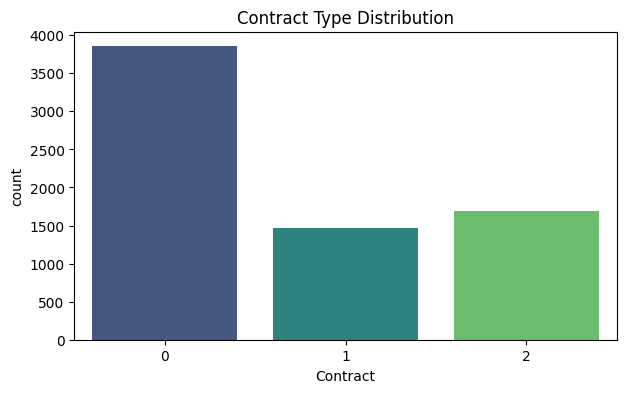

In [ ]:
# Purpose:
# Visualize the encoded Contract column.

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Contract", palette="viridis")

plt.title("Contract Type Distribution")
plt.show()

In [ ]:
# Purpose:
# Display the final summary of the project.

print("="*50)
print("Customer Churn Prediction Project Completed")
print("="*50)
print("Machine Learning Models Used")

print("----------------------------")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")
print("4. K-Nearest Neighbors")
print()
print("Best Model :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"],2),"%")
print()
print("Project Successfully Completed")

Customer Churn Prediction Project Completed
Machine Learning Models Used
----------------------------
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors

Best Model : Logistic Regression
Accuracy   : 79.57 %

Project Successfully Completed


1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors